# Extraindo arquivo de dados
Montando Google Drive, localizando e extraindo de `casos_obitos_doencas_preexistentes_diario.zip`, carregando os dados em um dataframe.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [1]:
!git clone https://github.com/vinimicius/COVID-ML.git

Cloning into 'COVID-ML'...
remote: Enumerating objects: 9, done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 9 (from 2)
Receiving objects: 100% (9/9), 70.41 MiB | 29.24 MiB/s, done.


In [2]:
import zipfile
import os

# 1. Caminhos definidos
zip_path = '/content/COVID-ML/data/data.zip'
extract_path = '/content/COVID-ML/data/'

# 2. Extração
print("Extraindo arquivos...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # Lista os arquivos dentro do zip para sabermos o nome original
    nomes_internos = zip_ref.namelist()
    print(f"Arquivo encontrado no ZIP: {nomes_internos[0]}")

    # Extrai tudo na pasta data
    zip_ref.extractall(extract_path)

# 3. Renomear para o padrão 'data.csv'
# Pegamos o primeiro arquivo extraído e renomeamos
nome_original = os.path.join(extract_path, nomes_internos[0])
nome_novo = os.path.join(extract_path, 'data.csv')

if os.path.exists(nome_original):
    os.rename(nome_original, nome_novo)
    print(f"✅ Sucesso! Arquivo extraído e salvo como: {nome_novo}")

Extraindo arquivos...
Arquivo encontrado no ZIP: casos_obitos_doencas_preexistentes.csv
✅ Sucesso! Arquivo extraído e salvo como: /content/COVID-ML/data/data.csv


In [4]:
import pandas as pd

# 1. Definir a raiz do projeto (ajuste se mudar o nome do repo)
project_root = '/content/COVID-ML'
data_dir = os.path.join(project_root, 'data')

# 2. Nome padronizado que definimos na extração
csv_file_name = 'data.csv'
csv_file_path = os.path.join(data_dir, csv_file_name)

# 3. Verificação de segurança antes de carregar
if os.path.exists(csv_file_path):
    print(f"✅ Arquivo encontrado! Carregando: {csv_file_path}")
    # Usando o low_memory=False pois arquivos de 2GB costumam ter colunas mistas
    df = pd.read_csv(csv_file_path, sep= ";", low_memory=False)
    print(f"📊 Dataset carregado com sucesso: {df.shape[0]} linhas e {df.shape[1]} colunas.")
else:
    print(f"❌ ERRO: O arquivo {csv_file_path} não foi encontrado.")
    print("Certifique-se de que a célula de extração foi executada corretamente.")

✅ Arquivo encontrado! Carregando: /content/COVID-ML/data/data.csv
📊 Dataset carregado com sucesso: 6734344 linhas e 20 colunas.


In [5]:
df.head()

,nome_munic,codigo_ibge,idade,cs_sexo,data_inicio_sintomas,obito,asma,cardiopatia,diabetes,doenca_hematologica,doenca_hepatica,doenca_neurologica,doenca_renal,imunodepressao,obesidade,outros_fatores_de_risco,pneumopatia,puerpera,sindrome_de_down,diagnostico_covid19
0,Assis,3504008,69.0,MASCULINO,2022-07-15T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO
1,São Paulo,3550308,60.0,FEMININO,2021-02-21T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO
2,Araraquara,3503208,58.0,MASCULINO,2021-06-23T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO
3,São Paulo,3550308,45.0,FEMININO,2021-02-03T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO
4,São Paulo,3550308,42.0,FEMININO,2021-02-23T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO


In [ ]:
import pandas as pd
import os

# Construct the full path to the extracted CSV file
csv_file_name = 'casos_obitos_doencas_preexistentes.csv'
csv_file_path = os.path.join(extraction_dir, csv_file_name)

print(f"Attempting to load data from: {csv_file_path}")

# Read the CSV file into a pandas DataFrame, specifying the semicolon as the separator
df = pd.read_csv(csv_file_path, sep=';')

print("Data loaded successfully into DataFrame 'df'.")
print("Displaying the first 5 rows of the DataFrame:")
df.head()

Attempting to load data from: /content/data_extracted/casos_obitos_doencas_preexistentes.csv
Data loaded successfully into DataFrame 'df'.
Displaying the first 5 rows of the DataFrame:


,nome_munic,codigo_ibge,idade,cs_sexo,data_inicio_sintomas,obito,asma,cardiopatia,diabetes,doenca_hematologica,doenca_hepatica,doenca_neurologica,doenca_renal,imunodepressao,obesidade,outros_fatores_de_risco,pneumopatia,puerpera,sindrome_de_down,diagnostico_covid19
0,Assis,3504008,69.0,MASCULINO,2022-07-15T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO
1,São Paulo,3550308,60.0,FEMININO,2021-02-21T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO
2,Araraquara,3503208,58.0,MASCULINO,2021-06-23T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO
3,São Paulo,3550308,45.0,FEMININO,2021-02-03T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO
4,São Paulo,3550308,42.0,FEMININO,2021-02-23T00:00:00Z,0,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,IGNORADO,CONFIRMADO


# Data processing

Filtrando apenas as linhas totalmente preenchidas do conjunto de dados, excluindo colunas irrelevantes e fazendo a troca de valores 'SIM' e 'NÃO' para 1 e 0. Aplicando OneHotEncoder para o gênero.

In [6]:
df_new = df.dropna()
df_new.drop(columns=['data_inicio_sintomas','codigo_ibge', 'diagnostico_covid19'], inplace=True)

disease_columns = [
    'asma', 'cardiopatia', 'diabetes', 'doenca_hematologica',
    'doenca_hepatica', 'doenca_neurologica', 'doenca_renal',
    'imunodepressao', 'obesidade', 'outros_fatores_de_risco',
    'pneumopatia', 'puerpera', 'sindrome_de_down'
]

mask = (df[disease_columns] != 'IGNORADO').all(axis=1)

df_new = df_new[mask]

df_new = df_new.drop(columns=['nome_munic'])
df_new.replace({'SIM': 1, 'NÃO': 0, '1':1, '0': 0}, inplace = True)
df_new.head()

/tmp/ipykernel_5891/2791636242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.drop(columns=['data_inicio_sintomas','codigo_ibge', 'diagnostico_covid19'], inplace=True)
/tmp/ipykernel_5891/2791636242.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_new = df_new[mask]
/tmp/ipykernel_5891/2791636242.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_new.replace({'SIM': 1, 'NÃO': 0, '1':1, '0': 0}, inplace = True)


,idade,cs_sexo,obito,asma,cardiopatia,diabetes,doenca_hematologica,doenca_hepatica,doenca_neurologica,doenca_renal,imunodepressao,obesidade,outros_fatores_de_risco,pneumopatia,puerpera,sindrome_de_down
4657,82.0,MASCULINO,1,0,0,1,0,0,0,0,0,0,1,0,0,0
4658,30.0,FEMININO,1,0,0,1,0,0,0,0,0,1,0,0,0,0
4659,32.0,MASCULINO,1,0,1,0,0,0,0,0,0,0,1,0,0,0
4660,69.0,MASCULINO,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4661,78.0,MASCULINO,1,0,0,0,0,0,0,0,0,0,1,0,0,0


In [12]:
!git config --global user.email "vinicius_martins@usp.br"
!git config --global user.name "Vinícius Martins"

In [13]:
# 1. Entrar na pasta do repositório
%cd /content/COVID-ML

# 2. Adicionar as mudanças (O .gitignore vai impedir que o data.csv de 2GB suba!)
!git add .

# 3. Criar a "etiqueta" da alteração
!git commit -m "Ajuste no notebook. Teste de push via Colab."

# 4. Enviar para a nuvem
!git push origin main

# 5. Voltar para a pasta principal do Colab
%cd /content

/content/COVID-ML
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
/content


In [ ]:
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(df_new[['cs_sexo']])
encoded_df = pd.DataFrame(encoded_data, columns=['F', 'M'], index=df_new.index)
df_new.drop(columns=['cs_sexo'], inplace=True)
df_new = pd.concat([encoded_df, df_new], axis = 1)

In [ ]:
df_new.shape

(201829, 17)

# Boxplot por doença

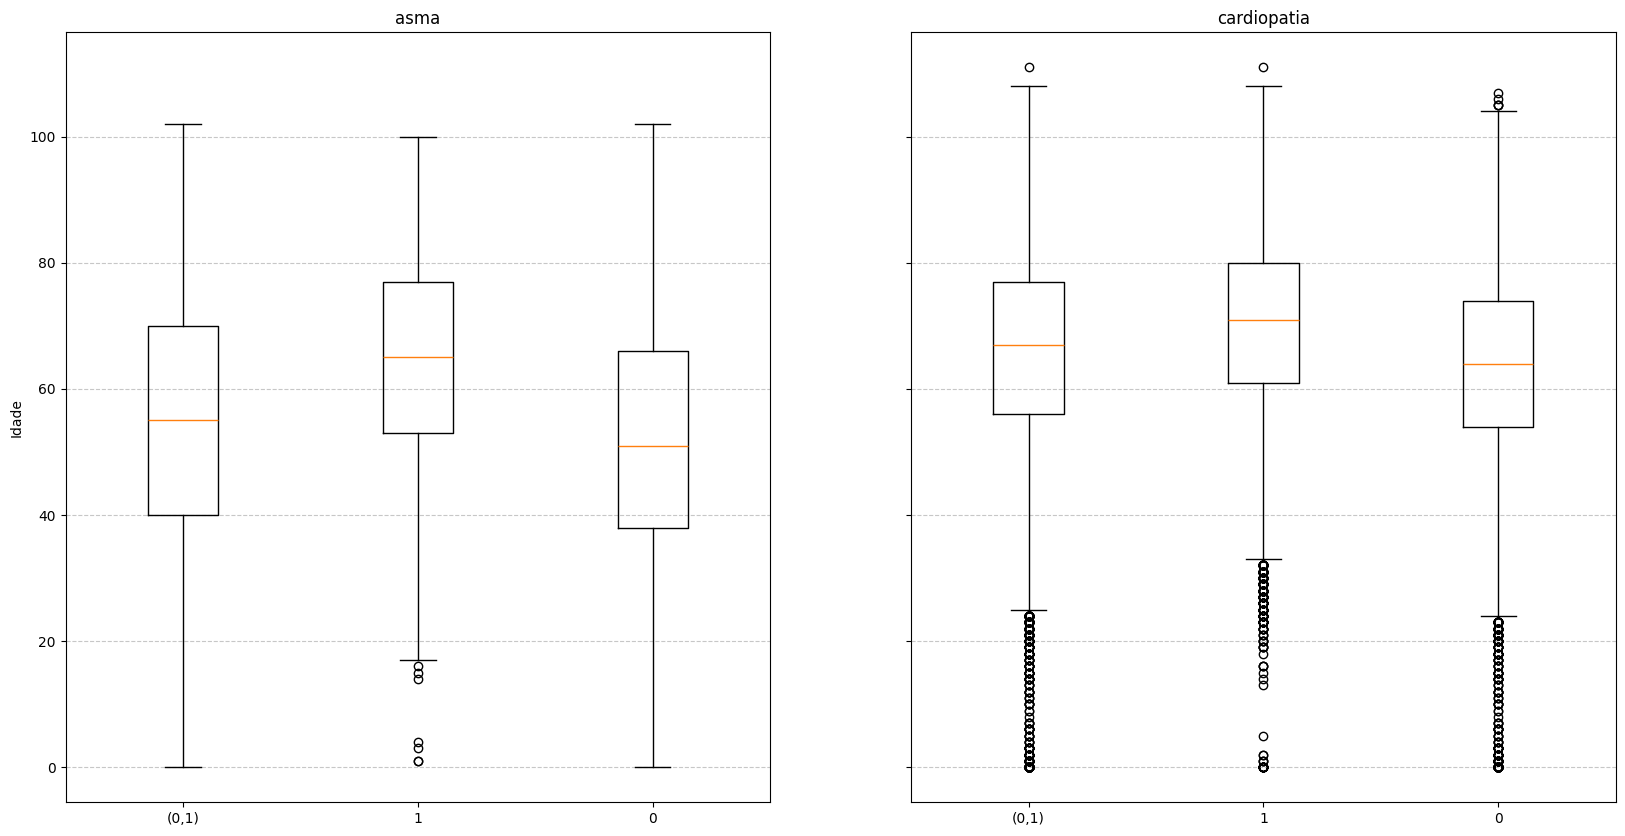

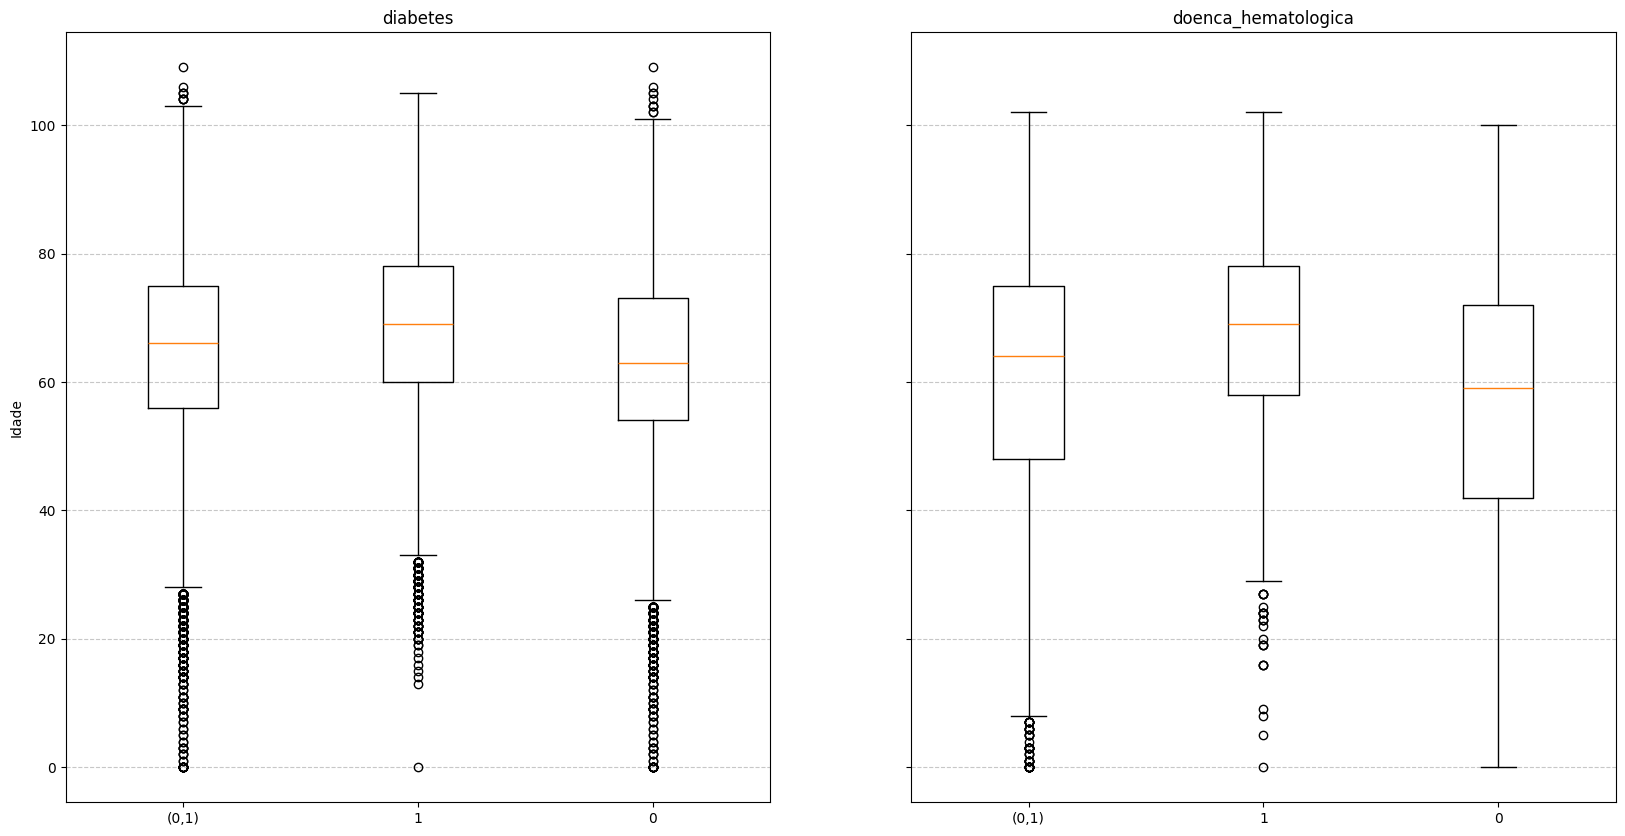

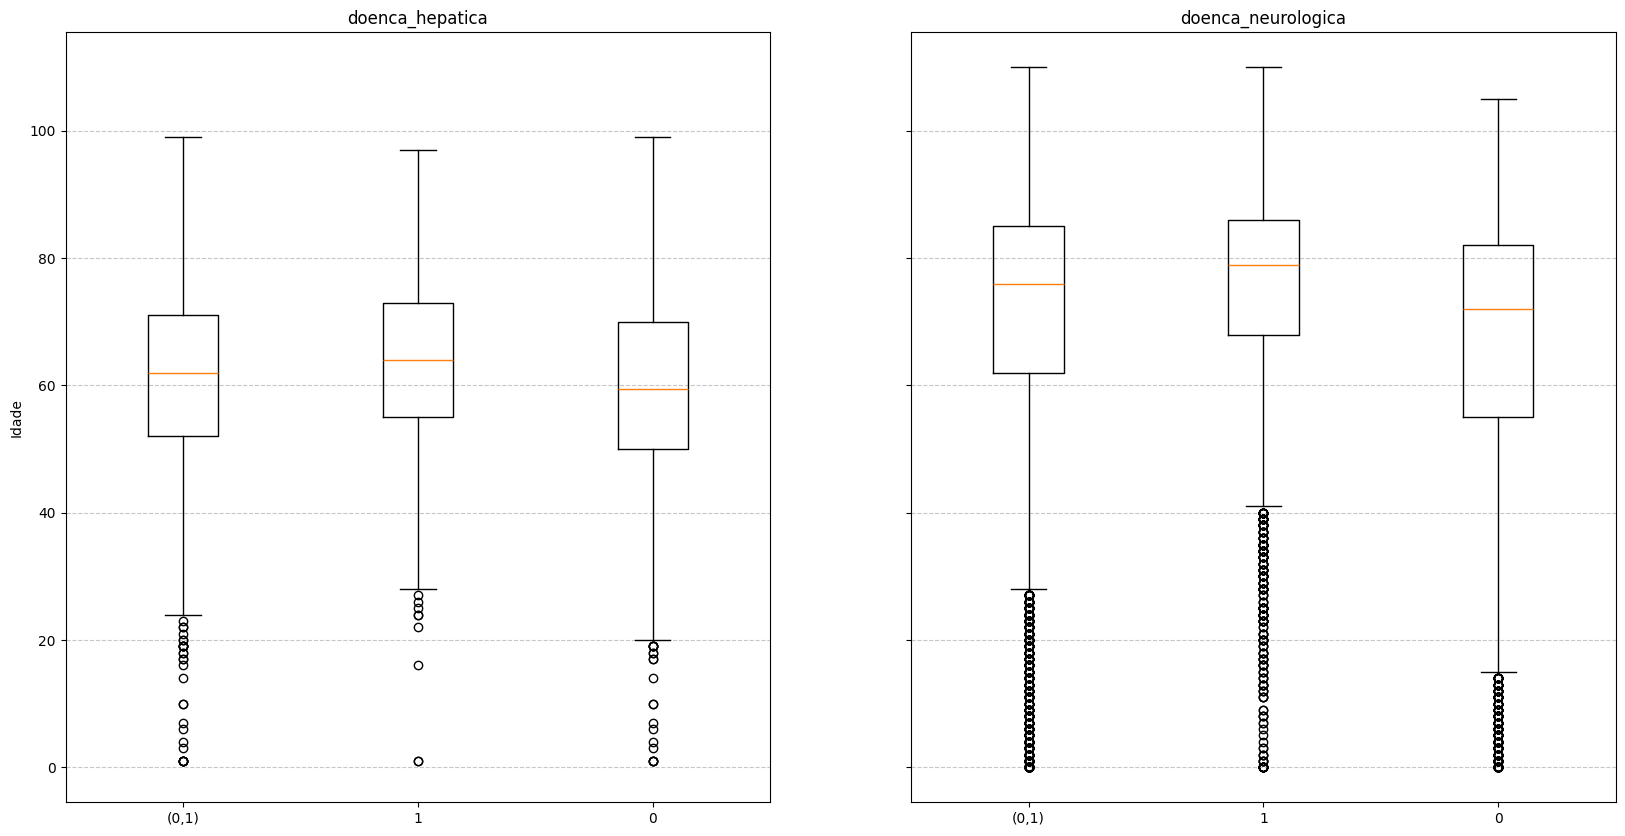

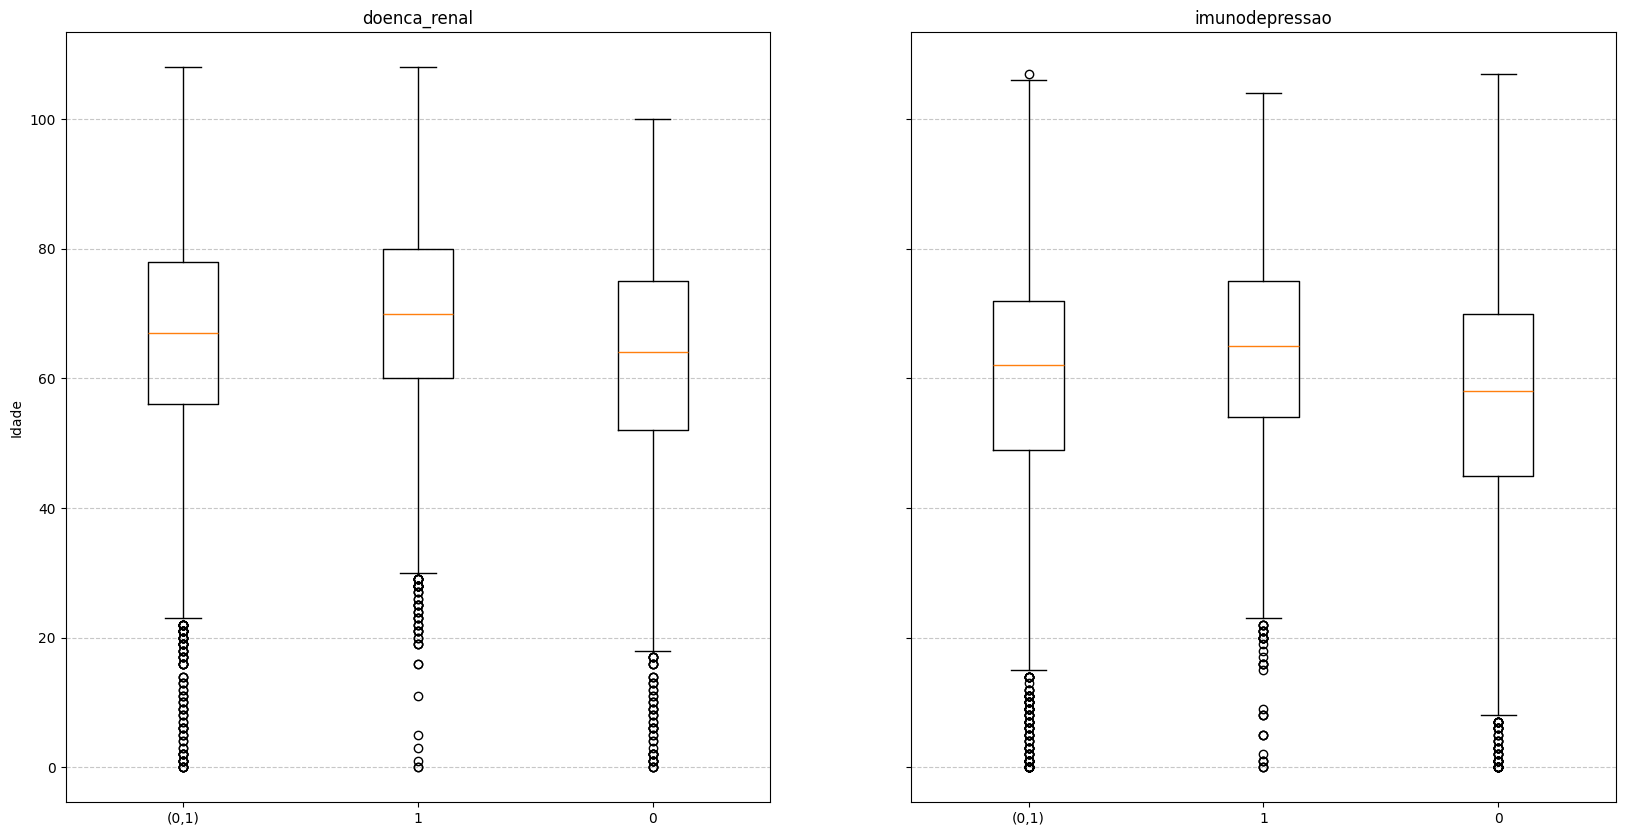

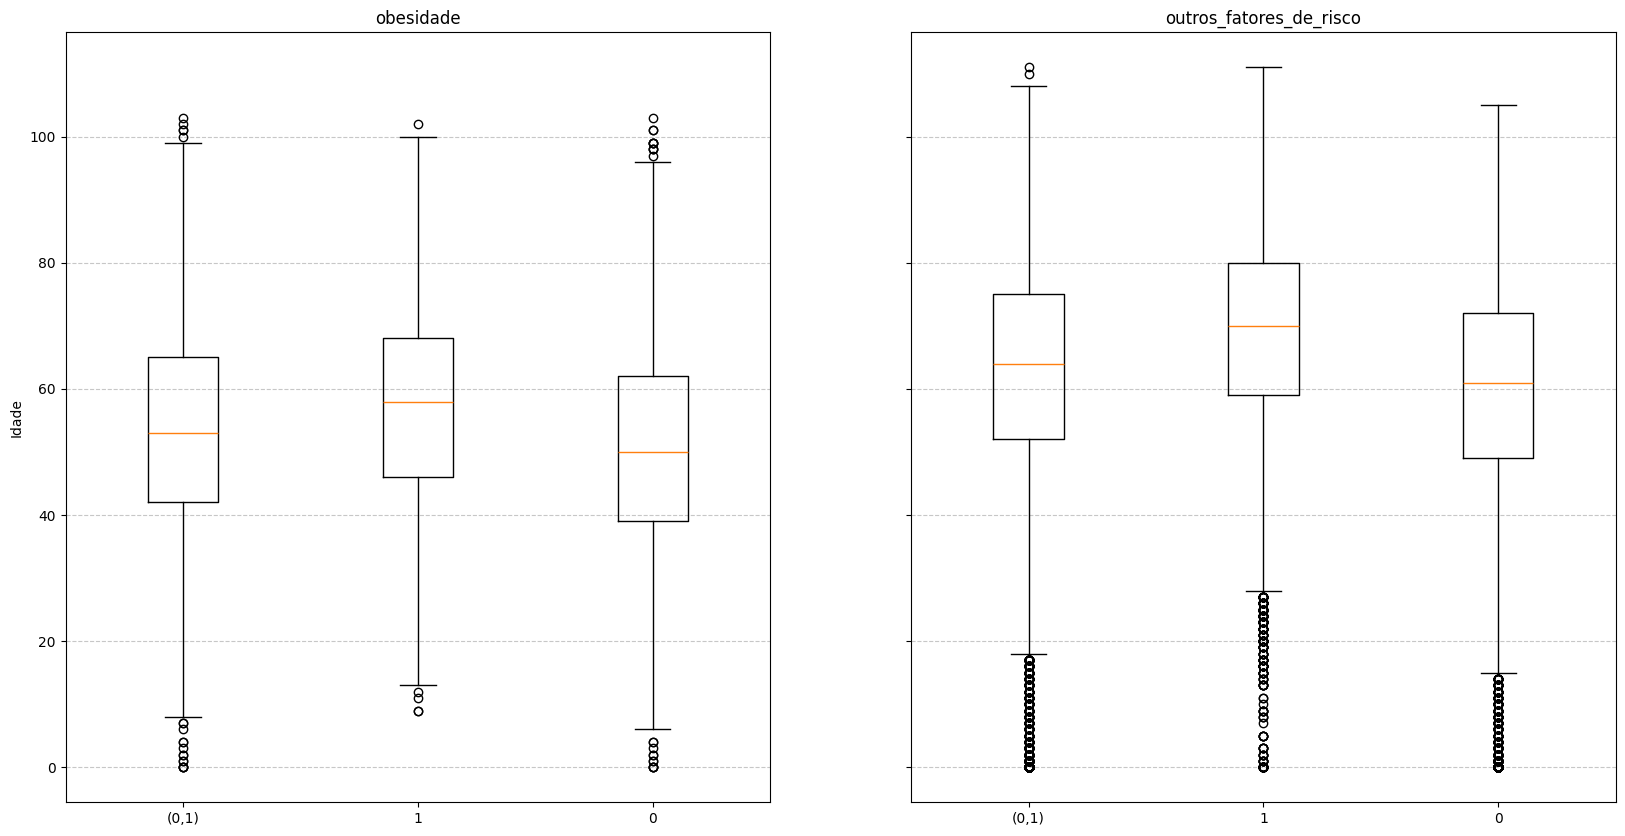

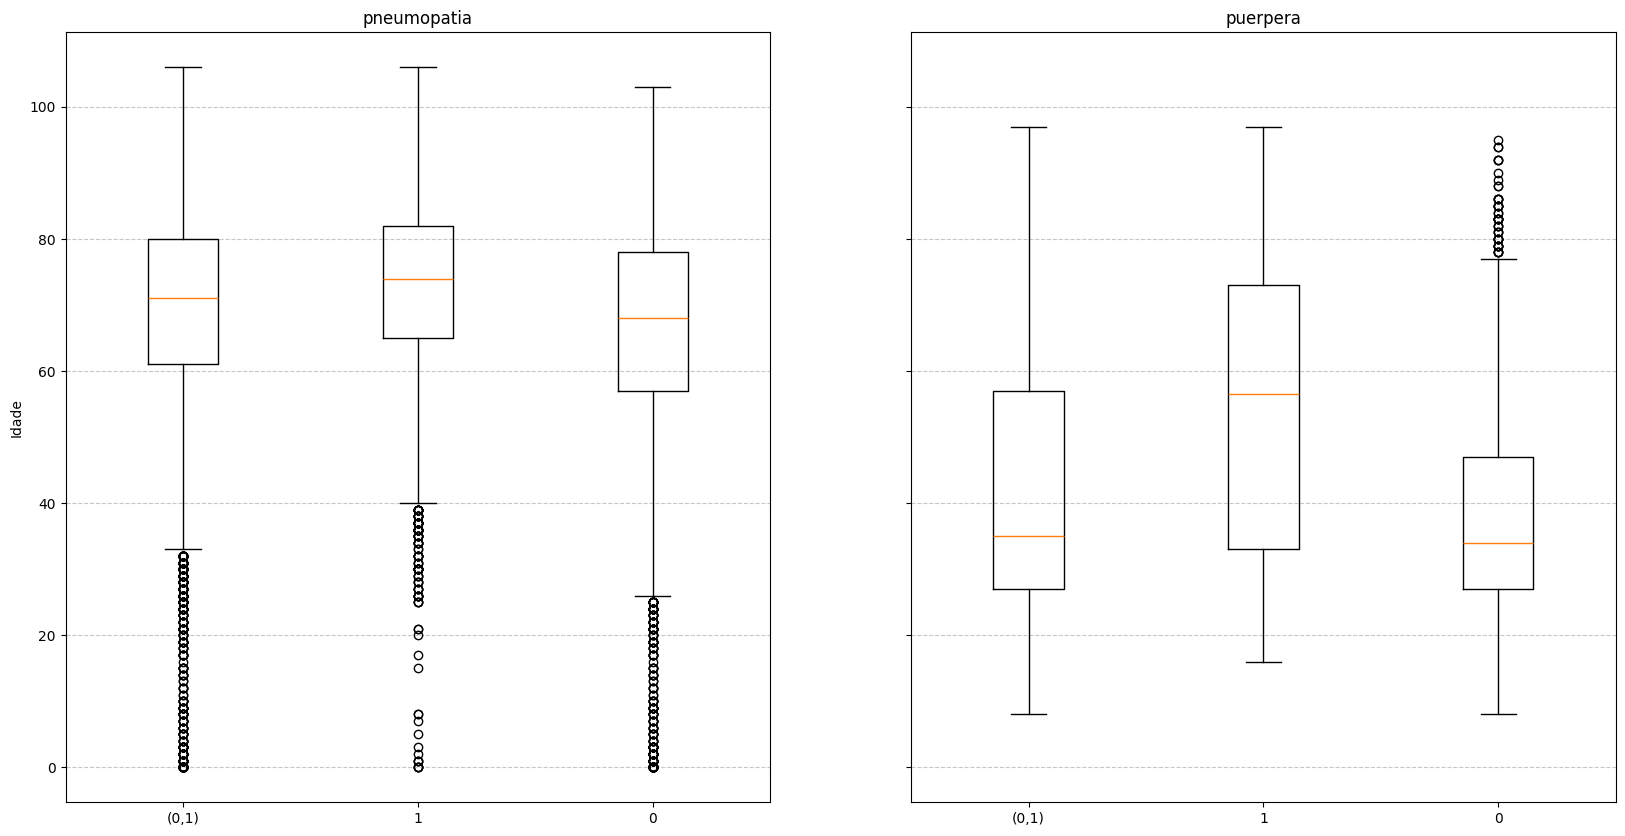

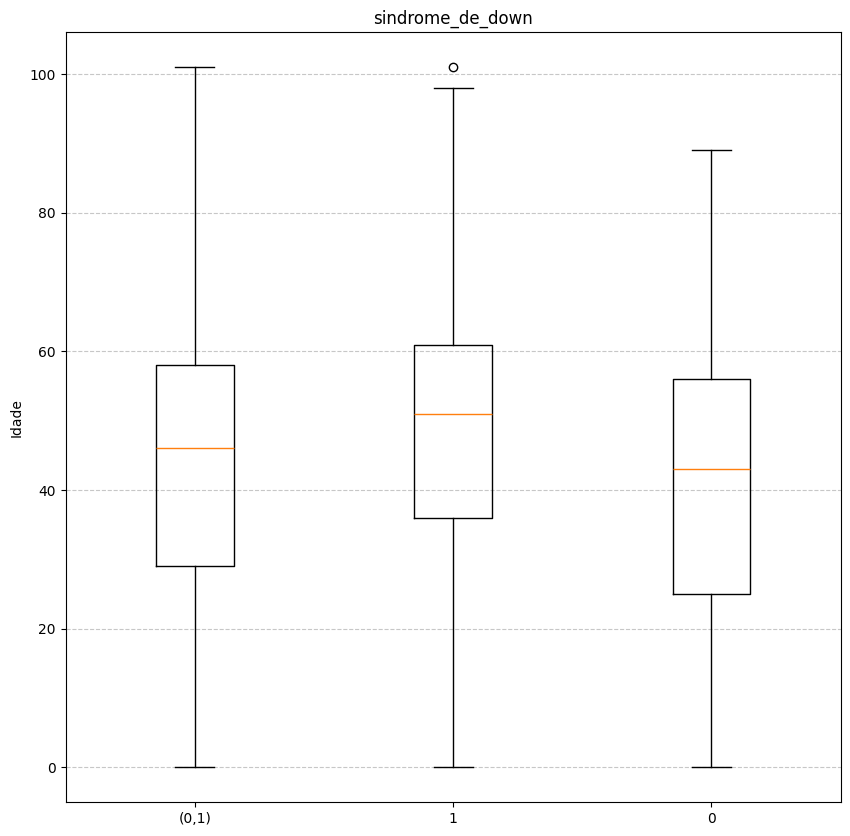

In [ ]:
from types import NoneType
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rows, cols = 1, 2
arr_stats = []
i=0
for disease in disease_columns:

    if i % 2 == 0:
        fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(20, 10), sharey=True) if disease!='sindrome_de_down' else plt.subplots(nrows=1, ncols=1, figsize=(10, 10), sharey=True)
        axs = axs.flatten() if disease!='sindrome_de_down' else [axs]
        i=0

    df_plot = df_new[df_new[disease] == 1]
    AIQ_total = df_plot['idade'].quantile(0.75) - df_plot['idade'].quantile(0.25)
    L1_total = df_plot['idade'].quantile(0.25) - 1.5*AIQ_total
    L2_total = df_plot['idade'].quantile(0.75) + 1.5*AIQ_total
    arr_stats.append([disease,
                      '(0,1)',
                      df_plot['idade'].min(),
                      L1_total if L1_total>df_plot['idade'].min() else df_plot['idade'].min(),
                      df_plot['idade'].quantile(0.25), df_plot['idade'].median(),
                      df_plot['idade'].quantile(0.75),
                      L2_total if L2_total<df_plot['idade'].max() else df_plot['idade'].max(),
                      df_plot['idade'].max()])

    df_plot_death = df_plot[df_plot['obito'] == 1]
    AIQ_death = df_plot_death['idade'].quantile(0.75) - df_plot_death['idade'].quantile(0.25)
    L1_death = df_plot_death['idade'].quantile(0.25) - 1.5*AIQ_death
    L2_death = df_plot_death['idade'].quantile(0.75) + 1.5*AIQ_death
    arr_stats.append([disease,
                      '1',
                      df_plot_death['idade'].min(),
                      L1_death if L1_death>df_plot_death['idade'].min() else df_plot_death['idade'].min(),
                      df_plot_death['idade'].quantile(0.25),
                      df_plot_death['idade'].median(),
                      df_plot_death['idade'].quantile(0.75),
                      L2_death if L1_death<df_plot_death['idade'].max() else df_plot_death['idade'].max(),
                      df_plot_death['idade'].max()])


    df_plot_survivor = df_plot[df_plot['obito'] == 0]
    AIQ_survivor = df_plot_survivor['idade'].quantile(0.75) - df_plot_survivor['idade'].quantile(0.25)
    L1_survivor = df_plot_survivor['idade'].quantile(0.25) - 1.5*AIQ_survivor
    L2_survivor = df_plot_survivor['idade'].quantile(0.75) + 1.5*AIQ_survivor
    arr_stats.append([disease,
                      '0',
                      df_plot_survivor['idade'].min(),
                      L1_survivor if L1_survivor>df_plot_survivor['idade'].min() else df_plot_survivor['idade'].min(),
                      df_plot_survivor['idade'].quantile(0.25),
                      df_plot_survivor['idade'].median(),
                      df_plot_survivor['idade'].quantile(0.75),
                      L2_survivor if L2_survivor<df_plot_survivor['idade'].max() else df_plot_survivor['idade'].max(),
                      df_plot_survivor['idade'].max()])

    ax = axs[i]
    ax.boxplot([df_plot['idade'], df_plot_death['idade'], df_plot_survivor['idade']], tick_labels=['(0,1)','1','0'])
    ax.set_title(disease)
    ax.set_ylabel('Idade') if i in [0,4,8,12] else NoneType
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if i % 4 == 3:
        fig.subplots_adjust(hspace=0.4)
        plt.show()
    i+=1

pdTotalStats = pd.DataFrame(arr_stats, columns=['doenca','status_obito','min','L1','1o_quartil','mediana','3o_quartil','L2','max'])


In [ ]:
pdTotalStats.to_excel('/content/drive/MyDrive/Mestrado/Matérias Cursadas/IA/Projeto/Artigo/diseases_stats.xlsx')
pdTotalStats.head()

,doenca,status_obito,min,L1,1o_quartil,mediana,3o_quartil,L2,max
0,asma,"(0,1)",0.0,0.0,40.0,55.0,70.0,102.0,102.0
1,asma,1,1.0,17.0,53.0,65.0,77.0,113.0,100.0
2,asma,0,0.0,0.0,38.0,51.0,66.0,102.0,102.0
3,cardiopatia,"(0,1)",0.0,24.5,56.0,67.0,77.0,108.5,111.0
4,cardiopatia,1,0.0,32.5,61.0,71.0,80.0,108.5,111.0
